In [1]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from scipy.special import factorial
from scipy.stats import binned_statistic
from matplotlib.ticker import ScalarFormatter

The recursive method with Density of States (DoS) is implemented as follows:
- setup_DoS: defines the number of DoS bins and bin size $\Delta \omega_{DoS}$ (currently 0.05 meV so we don't loose too much information).    
    Calculates the integrated structure factor $\int_\omega^{\omega+\Delta\omega_{DoS}} S(q, \omega') d\omega'$ so we don't need to keep track of each individual $S$ and $\omega$
- get_diag_ini: get the incoherent approximation of $S^{(1)}$
- update_s_factor: update the integrated structure factor.  
    it calls 
    - get_diag_rec: calculate $S(q, \omega)$ of next order using the recursive relation
    - get_int_s_factor: inside each DoS bin with size $\Delta  \omega_{DoS}$, calculate $\int_\omega^{\omega+\Delta \omega_{DoS}} S(q, \omega') d\omega'$
- get_binned_s_factor: returns $S_{binned} = \frac{\int_\omega^{\omega+\Delta\omega} S(q, \omega') d\omega'}{\Delta\omega}$. Here $\Delta\omega$ can be different from $\Delta\omega_{DoS}$. Choosing a larger $\Delta\omega$ (currently 1 mev) to smooth out the $S(q, \omega)$ curve. 

In [17]:
class StructureFactor1D:
    def __init__(self, nLattice,q_value,prevS=None,prevSbinned = None, mass=26161e3, omegaNaught=10e-6, latticeConst=2*np.pi/2.28, couplingConst=28, energyThreshold = 1e-6):
        self.nLattice = nLattice # number of lattice
        # self.nPhononMax = nPhononMax
        self.mass = mass # Silicon: 26161e3 keV
        self.omegaNaught = omegaNaught # Silicon: 10e-6 keV, maximum energy 20 meV
        self.latticeConst = latticeConst # Silicon: 2*np.pi/2.28 keV^-1
        self.couplingConst = couplingConst # A, default: 28 for silicon
        self.volume = nLattice*8/(latticeConst**3) # propotional to nLattice
        self.prevS = prevS # (2,L) array containing L structure factors and its corresponding omega
        self.prevSbinned = prevSbinned # (2,L) array containing the sum of structure factors and its corresponding omega
        self.q_value = q_value
        self.omegaList = 2*self.omegaNaught*np.sin(np.pi*np.arange(1, self.nLattice)/self.nLattice) # num of energy levels: nLattice-1
        filter = np.argwhere(self.omegaList >= energyThreshold)
        self.omegaList = self.omegaList[filter].reshape(-1)
        self.nuList = np.arange(1, self.nLattice)[filter]

    def getDebyeWallerConst(self):
        '''
        Get W(q) appearing in the debye waller factor
        '''
        return self.q_value**2 / (4*self.mass*self.nLattice) * np.sum(1/self.omegaList)
        
    def partition(self, max_range, max_sum):
        max_range = np.asarray(max_range, dtype = int).ravel()        
        if(max_range.size == 1):
            return np.arange(min(max_range[0],max_sum) + 1, dtype = int).reshape(-1,1)
        P = self.partition(max_range[1:], max_sum)
        # S[i] is the largest summand we can place in front of P[i]            
        S = np.minimum(max_sum - P.sum(axis = 1), max_range[0])
        offset, sz = 0, S.size
        out = np.empty(shape = (sz + S.sum(), P.shape[1]+1), dtype = int)
        out[:sz,0] = 0
        out[:sz,1:] = P
        for i in range(1, max_range[0]+1):
            ind, = np.nonzero(S)
            offset, sz = offset + sz, ind.size
            out[offset:offset+sz, 0] = i
            out[offset:offset+sz, 1:] = P[ind]
            S[ind] -= 1
        return out
    
    def partitionwfilter(self, max_range, max_sum):
        arr = self.partition(max_range, max_sum)
        return arr[np.argwhere(np.sum(arr, axis=1) == max_sum)].reshape(-1, len(max_range))
    
    def getJVector(self, nPhonon):
        '''
        Get all posible sets of j_nu given the total number of phonons. 
        nPhonon: int
        '''
        jVector = self.partitionwfilter(nPhonon*np.ones(len(self.omegaList)), nPhonon)
        return jVector

    def get_allowed_omega(self, nPhonon):
        jVector = self.getJVector(nPhonon)
        allowed_omega = np.sum(np.multiply(self.omegaList, jVector),axis=1)
        return allowed_omega

    def get_diag_ini(self):
        '''
        Get IntS of order 1
        '''
        print('Processing n = 1...')
        self.sOrder = 1
        DWfactor =  np.exp(- 2 * self.getDebyeWallerConst()) 
        s_values = 2 * np.pi / self.volume * self.nLattice * DWfactor * self.couplingConst**2 *  (self.q_value**2 /(2*self.mass*self.nLattice)) / self.omegaList
        self.currIntS = self.get_int_s_factor(np.row_stack((self.omegaList, s_values)))
        # return self.currIntS

    def get_diag_rec(self,):
        '''
        Use the recursive relation to calculate the structure factor of nPhonon-th order
        prevS: (2,a) array, first row: omega list 
                            second row: structure factor integrated over omega in bins defined by setup_DoS (int_{omega}^{omega+Delta omega} S d(omega'))
        --------returns--------
        newS: (2,a*len(omegaList)) array
        '''
        newIntS = (self.q_value**2 /(2*self.mass*self.nLattice))/self.sOrder * self.currIntS[1,:, np.newaxis] / self.omegaList 
        newOmega = self.currIntS[0,:, np.newaxis] + self.omegaList 
        return np.row_stack((newOmega.T.reshape(-1,), newIntS.T.reshape(-1,)))
    
    def setup_DoS(self,max_omega, nBins=500):
        '''
        Set up the DoS function. 
        '''
        self._DoS_max_omega = max_omega
        self._DoS_min_omega = 0 
        self._DoS_nBins = nBins
        # self._DoS_x_list, self._DoS_delta_omega = np.linspace(0, max_omega,nBins, retstep=True) 


    def get_int_s_factor(self,sFactor):
        '''
        Integrate the structure factor over omega in bins defined by setup_DoS (int_{omega}^{omega+Delta omega} S d(omega')) 
        --------returns--------
        intS: (2,DoS_nBins) array
        '''
        allowed_omegas = sFactor[0,:]
        s_diag = sFactor[1,:]
        result = binned_statistic(allowed_omegas, s_diag, statistic="sum",bins=self._DoS_nBins, range=(self._DoS_min_omega, self._DoS_max_omega))
        # np.nan_to_num(result.statistic, nan=0.0)
        return np.row_stack((self._DoS_x_list,result.statistic))
    

    def update_s_factor(self):
        self.sOrder += 1
        print(f'Processing n = {self.sOrder}...')
        sFactor = self.get_diag_rec()
        self.currIntS = self.get_int_s_factor(sFactor)
    

    def get_binned_s_factor(self, xlist, delta_omega):
        allowed_omegas = self.currIntS[0,:]
        s_diag = self.currIntS[1,:]
        result = binned_statistic(allowed_omegas, s_diag, statistic="sum",bins=len(xlist), range=(min(xlist), max(xlist)))
        ylist = result.statistic/delta_omega
        return ylist

    def get_diag(self, nPhonon):
        factor = 2 * np.pi / self.volume * np.exp(- 2 * self.getDebyeWallerConst()) 
        jVector = self.getJVector(nPhonon)
        prod_part = np.prod(1/(factorial(jVector)*(self.omegaList ** jVector)), axis=1)
        return factor * self.nLattice * self.couplingConst**2 * (self.q_value**2 /(2*self.mass*self.nLattice))**nPhonon * prod_part
    
    def get_binned_s_diag(self,nPhonon, xlist, delta_omega):
        allowed_omegas = self.get_allowed_omega(nPhonon)
        s_diag = self.get_diag(nPhonon)
        result = binned_statistic(allowed_omegas, s_diag, statistic="sum",bins=len(xlist), range=(min(xlist), max(xlist)))
        ylist = result.statistic/delta_omega
        return xlist, ylist
    

    # WIP
    def get_c_offdiag_init(self, l_diff): # l' minus l
        DWfactor =  np.exp(- 2 * self.getDebyeWallerConst()) 
        offdiag_factor = x
        return 2 * np.pi / self.volume * DWfactor * self.couplingConst**2 *  (self.q_value**2 /(2*self.mass*self.nLattice)) / self.omegaList

    def get_coherent_rec(self, nPhonon, prevS):
        pass 
        # return

   
    # def get_off_diag_sum_jVec_single_n_real_part(self, nPhonon, xi): 
    #     '''
    #     xi: integer, defined as l-l' 
    #     --------returns--------
    #     the summation of j_nu vectors
    #     '''
    #     # dont forget to multiply 2 when calculating the structure factor
    #     jVector = self.getJVector(nPhonon)
    #     # print("xi",xi)
    #     cos_part = np.cos(xi * ((self.q_list[np.newaxis, :] * self.latticeConst) 
    #                             - 2 * np.pi * np.einsum('i,ji->j',np.arange(1, self.nLattice), jVector)[:, np.newaxis] / self.nLattice)) 
    #     prod_part = np.prod(1/(factorial(jVector)*(self.omegaList ** jVector)), axis=1)
    #     return np.sum(prod_part[:, np.newaxis]*cos_part,axis=0)
    
    # # WIP
    # def get_off_diag_sum_jVec_single_n_real_part(self, nPhonon, xi): 
    #     '''
    #     xi: integer, defined as l-l' 
    #     --------returns--------
    #     the summation of j_nu 
    #     '''
    #     # dont forget to multiply 2 when calculating the structure factor
    #     jVector = self.getJVector(nPhonon)
    #     # print("xi",xi)
    #     cos_part = np.cos(xi * ((self.q_value * self.latticeConst)- 2 * np.pi * np.einsum('i,ji->j',np.arange(1, self.nLattice), jVector)/ self.nLattice)) 
    #     prod_part = np.prod(1/(factorial(jVector)*(self.omegaList ** jVector)), axis=1)
    #     return prod_part*cos_part
    
    # # WIP
    # def get_off_diag(self, nPhonon):
    #     2 * (self.nLattice-xi) * self


# N-site lattice, calculated using the recursive relation

Processing n = 1...
Plotting n = 1...
Processing n = 2...
Plotting n = 2...
Processing n = 3...
Plotting n = 3...
Processing n = 4...
Plotting n = 4...
Processing n = 5...
Plotting n = 5...
Processing n = 6...
Plotting n = 6...
Processing n = 7...
Plotting n = 7...
Processing n = 8...
Plotting n = 8...
Processing n = 9...
Plotting n = 9...
Processing n = 10...
Plotting n = 10...


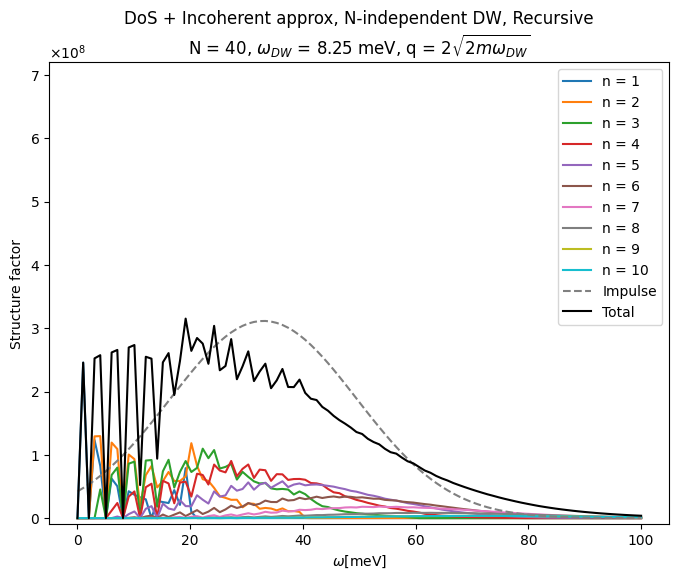

In [13]:
class StructureFactor1D_NIndepDW(StructureFactor1D):
    def getDebyeWallerConst(self):
        return self.q_value**2 / (4*self.mass*8.25e-6) # take W(q) = q^2/(4 m omega_DW) 

multplier = 2
q_value  = multplier*np.sqrt(2*26161e3*8.25e-6)
nLattice = 40
test = StructureFactor1D_NIndepDW(nLattice = nLattice,q_value=q_value, couplingConst=28,)
fmt = ['r-', 'g-', 'b-', 'y-', 'c-']
max_omega = 100*1e-6 # keV
xlist, delta_omega = np.linspace(0, max_omega,100, retstep=True) 
# impulse approx
deltasq = q_value**2 * 8.25e-6/(2*test.mass)
ia =  28**2 / (8/(test.latticeConst**3)) * np.sqrt(2*np.pi/deltasq) * np.exp(- (xlist-(q_value**2/(2*test.mass)))**2 / (2*deltasq))
sum = np.zeros(xlist.shape)
fig, ax = plt.subplots(figsize=(8,6))

nPhonon = 10

test.setup_DoS(max_omega, nBins=2000)
test.get_diag_ini()
for i in range(1,nPhonon):
    s_diag = test.get_binned_s_factor(xlist, delta_omega)
    s_diag = np.nan_to_num(s_diag, nan=0.0)
    sum += s_diag
    print(f'Plotting n = {i}...')
    ax.plot(xlist*1e6, s_diag,label=f'n = {i}')
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((8,8))
    ax.yaxis.set_major_formatter(formatter)
    test.update_s_factor()
print(f'Plotting n = {nPhonon}...')
ax.plot(xlist*1e6, s_diag,label=f'n = {nPhonon}')
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((8,8))
ax.yaxis.set_major_formatter(formatter)
ax.plot(xlist*1e6, ia, linestyle="--", color="gray", label='Impulse')
ax.plot(xlist*1e6,sum, label="Total",color="black")
txt1 = r"$\omega_{DW}$" #r"exp$(\frac{q^2}{4m\omega_{DW}})$"
txt2 = r"$\sqrt{2m\omega_{DW}}$" 
plt.ylim(-0.1e8, 7.2e8)
plt.title(f'DoS + Incoherent approx, N-independent DW, Recursive\nN = {nLattice}, {txt1} = 8.25 meV, q = {multplier}{txt2}')# , {txt} = {test.omegaNaught*1e6} meV
plt.ylabel('Structure factor')
plt.xlabel(r'$\omega$[meV]')
plt.legend()
plt.savefig(f"sfactorwrtomega_q{int(q_value)}_{nLattice}lattice_NindepDW_energyCut_recur_DoS", bbox_inches="tight")

39


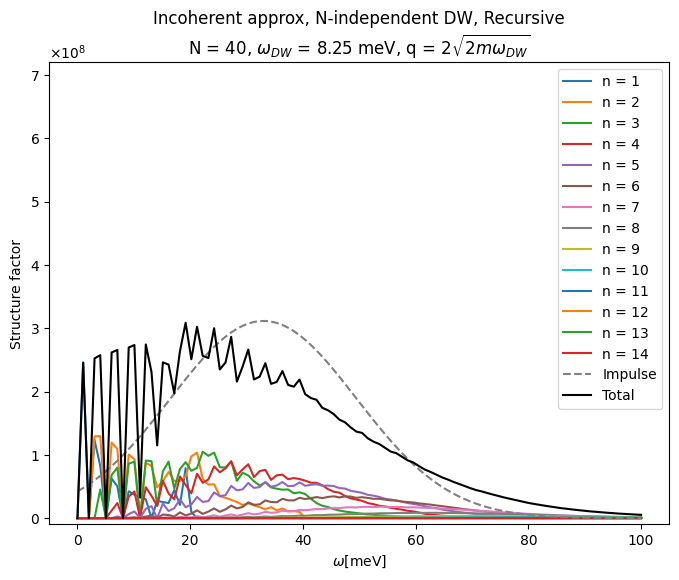

In [ ]:
# tests of DoS just to keep a record



# class StructureFactor1D_NIndepDW(StructureFactor1D):
#     def getDebyeWallerConst(self):
#         return self.q_value**2 / (4*self.mass*8.25e-6) # take W(q) = q^2/(4 m omega_DW) 

# multplier = 2
# q_value  = multplier*np.sqrt(2*26161e3*8.25e-6)
# nLattice = 40
# test = StructureFactor1D_NIndepDW(nLattice = nLattice,q_value=q_value, couplingConst=28,)
# fmt = ['r-', 'g-', 'b-', 'y-', 'c-']
# max_omega = 100*1e-6 # keV
# xlist, delta_omega = np.linspace(0, max_omega,100, retstep=True) 
# # impulse approx
# deltasq = q_value**2 * 8.25e-6/(2*test.mass)
# ia =  28**2 / (8/(test.latticeConst**3)) * np.sqrt(2*np.pi/deltasq) * np.exp(- (xlist-(q_value**2/(2*test.mass)))**2 / (2*deltasq))
# sum = np.zeros(xlist.shape)
# fig, ax = plt.subplots(figsize=(8,6))

# prevS = test.get_diag_ini()
# omegalist, s_diag = test._bin_s_factor(prevS,xlist, delta_omega)
# sum = sum+s_diag
# ax.plot(omegalist*1e6, s_diag,label=f'n = {1}')
# print(len(prevS[1,:]))
# for i in range(2,5,):
#     # omegas = test.get_allowed_omega(i) # x axis: omega
#     newS = test.get_diag_rec(i,prevS) # y axis: S, diag part
#     omegalist, s_diag = test._bin_s_factor(newS,xlist, delta_omega)
#     prevS = newS
#     s_diag = np.nan_to_num(s_diag, nan=0.0)
#     # fil = omegalist <= max_omega
#     # omegalist, s_diag = omegalist[fil], s_diag[fil]
#     sum = sum+s_diag
#     ax.plot(omegalist*1e6, s_diag,label=f'n = {i}')
#     formatter = ScalarFormatter(useMathText=True)
#     formatter.set_powerlimits((8,8))
#     ax.yaxis.set_major_formatter(formatter)
#     # ax.ticklabel_format(style="sci",  axis="y", scilimits=(0,0))
# _x_list, _delta_omega = np.linspace(0, max_omega,500, retstep=True) 
# prevS = np.row_stack(test._bin_s_factor(newS,_x_list, _delta_omega))[::-1]
# for i in range(5,15):
#     newS = test.get_diag_rec(i,prevS)   
#     omegalist, s_diag = test._bin_s_factor(newS,xlist, delta_omega)
#     s_diag = _delta_omega*s_diag
#     prevS = np.row_stack(test._bin_s_factor(newS,_x_list, _delta_omega))[::-1]
#     prevS[0,:] = prevS[0,:] * _delta_omega
#     s_diag = np.nan_to_num(s_diag, nan=0.0)
#     # fil = omegalist <= max_omega
#     # omegalist, s_diag = omegalist[fil], s_diag[fil]
#     sum = sum+s_diag
#     ax.plot(omegalist*1e6, s_diag,label=f'n = {i}')
#     formatter = ScalarFormatter(useMathText=True)
#     formatter.set_powerlimits((8,8))
#     ax.yaxis.set_major_formatter(formatter)
# ax.plot(xlist*1e6, ia, linestyle="--", color="gray", label='Impulse')
# ax.plot(xlist*1e6,sum, label="Total",color="black")
# txt1 = r"$\omega_{DW}$" #r"exp$(\frac{q^2}{4m\omega_{DW}})$"
# txt2 = r"$\sqrt{2m\omega_{DW}}$" 
# plt.ylim(-0.1e8, 7.2e8)
# plt.title(f'Incoherent approx, N-independent DW, Recursive\nN = {nLattice}, {txt1} = 8.25 meV, q = {multplier}{txt2}')# , {txt} = {test.omegaNaught*1e6} meV
# plt.ylabel('Structure factor')
# plt.xlabel(r'$\omega$[meV]')
# plt.legend()
# plt.savefig(f"sfactorwrtomega_q{int(q_value)}_{nLattice}lattice_NindepDW_energyCut_recur", bbox_inches="tight")


In [5]:
# class StructureFactor1D_NIndepDW(StructureFactor1D):
#     def getDebyeWallerConst(self):
#         return self.q_value**2 / (4*self.mass*12e-6) # take W(q) = q^2/(4 pi m2omega0) 

In [6]:
# plt.hist(StructureFactor1D(nLattice = 6000,q_value=25).omegaList*1e6,bins=20)

In [7]:
for i in [10, 25, 30, 100, 200, 500,1000,10000,20000,30000,1e6]:
    omegas = StructureFactor1D(nLattice = i,q_value=25).omegaList
    # filter = np.argwhere(omegas >= 1e-6)
    # omegas = omegas[filter]
    totinvomg = np.mean(1/omegas)
    print("NLattice:", i)
    print('Sum of inverse omega:', totinvomg)

NLattice: 10
Sum of inverse omega: 85832.21995491028
NLattice: 25
Sum of inverse omega: 110887.54273022992
NLattice: 30
Sum of inverse omega: 116128.60234672674
NLattice: 100
Sum of inverse omega: 122422.14386289085
NLattice: 200
Sum of inverse omega: 118429.97327506139
NLattice: 500
Sum of inverse omega: 122966.03323374708
NLattice: 1000
Sum of inverse omega: 122033.95586969686
NLattice: 10000
Sum of inverse omega: 121211.68258470815
NLattice: 20000
Sum of inverse omega: 121257.05809408688
NLattice: 30000
Sum of inverse omega: 121272.19425879541
NLattice: 1000000.0
Sum of inverse omega: 121261.60929830722


In [8]:
1/110887.54273022992

9.018145549792061e-06

# N-site lattice, no recursive relation

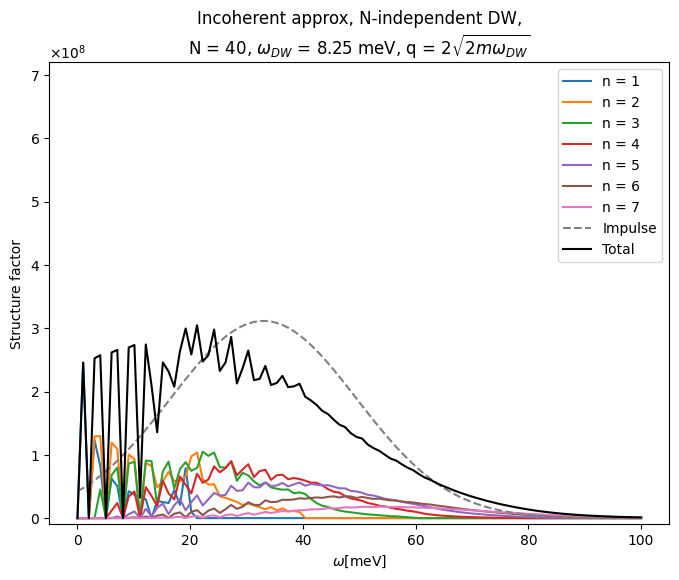

In [ ]:
# class StructureFactor1D_NIndepDW(StructureFactor1D):
#     def getDebyeWallerConst(self):
#         return self.q_value**2 / (4*self.mass*8.25e-6) # take W(q) = q^2/(4 m omega_DW) 

# multplier = 2
# q_value  = multplier*np.sqrt(2*26161e3*8.25e-6)
# nLattice = 40
# test = StructureFactor1D_NIndepDW(nLattice = nLattice,q_value=q_value, couplingConst=28,)
# fmt = ['r-', 'g-', 'b-', 'y-', 'c-']
# max_omega = 100*1e-6 # keV
# xlist, delta_omega = np.linspace(0, max_omega, 100, retstep=True) 
# # impulse approx
# deltasq = q_value**2 * 8.25e-6/(2*test.mass)
# ia =  28**2 / (8/(test.latticeConst**3)) * np.sqrt(2*np.pi/deltasq) * np.exp(- (xlist-(q_value**2/(2*test.mass)))**2 / (2*deltasq))
# sum = np.zeros(xlist.shape)
# # plot
# fig, ax = plt.subplots(figsize=(8,6))
# for i in range(1,8,):
#     # omegas = test.get_allowed_omega(i) # x axis: omega
#     omegalist, s_diag = test.get_binned_s_diag(i,xlist, delta_omega) # y axis: S, diag part
#     # markerline, stemlines, baseline  = plt.stem(np.linspace(0,100,100), s_diag, linefmt=fmt[i-1],markerfmt=' ', basefmt="w",label=f'n = {i}')
#     s_diag = np.nan_to_num(s_diag, nan=0.0)
#     fil = omegalist <= max_omega
#     omegalist, s_diag = omegalist[fil], s_diag[fil]
#     sum = sum+s_diag
#     ax.plot(omegalist*1e6, s_diag,label=f'n = {i}')
#     formatter = ScalarFormatter(useMathText=True)
#     formatter.set_powerlimits((8,8))
#     ax.yaxis.set_major_formatter(formatter)
#     # ax.ticklabel_format(style="sci",  axis="y", scilimits=(0,0))
# ax.plot(xlist*1e6, ia, linestyle="--", color="gray", label='Impulse')
# ax.plot(xlist*1e6,sum, label="Total",color="black")
# txt1 = r"$\omega_{DW}$" #r"exp$(\frac{q^2}{4m\omega_{DW}})$"
# txt2 = r"$\sqrt{2m\omega_{DW}}$"
# plt.ylim(-0.1e8, 7.2e8)
# plt.title(f'Incoherent approx, N-independent DW,\nN = {nLattice}, {txt1} = 8.25 meV, q = {multplier}{txt2}')# , {txt} = {test.omegaNaught*1e6} meV
# plt.ylabel('Structure factor')
# plt.xlabel(r'$\omega$[meV]')
# plt.legend()
# plt.savefig(f"sfactorwrtomega_q{int(q_value)}_{nLattice}lattice_NindepDW_energyCut", bbox_inches="tight")
